# Naive Bayes
- Dataset: 
    1. Titanic https://www.kaggle.com/datasets/yasserh/titanic-dataset
    2. Wine https://www.kaggle.com/datasets/yasserh/wine-quality-dataset
    3. Breast Cancer https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
- Types of Naive Bayes
    1. Gaussian Naive Bayes
    2. Multinomial Naive Bayes
    3. Bernoulli Naive Bayes
- References:
    1. https://youtu.be/GBMMtXRiQX0?si=fAGQN-Mg1xvHUEOX
    2. https://www.geeksforgeeks.org/machine-learning/naive-bayes-classifiers/

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def run_naive_bayes(file_path, target_col, cols_to_drop=None):
    print(f"Loading and processing: {file_path}...")
    
    #load dataset
    df = pd.read_csv(file_path)
    
    #drop unnecessary columns (like IDs, Names, etc.)
    if cols_to_drop:
        df = df.drop(columns=cols_to_drop, errors='ignore')
        
    #Separate Features and Target
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    #identify categorical and numerical columns
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
    categorical_features = X.select_dtypes(include=['object', 'category', 'str']).columns
    
    #preprocessing Pipelines
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        # Note: Naive Bayes doesn't actually *need* scaling, but keeping it 
        # makes this pipeline 100% interchangeable with your KNN and Tree code.
        ('scaler', StandardScaler()) 
    ])
    
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])
    
    #Final Pipeline with GaussianNB
    nb_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', GaussianNB())
    ])
    
    #split data - train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    
    #Train and Predict
    nb_pipeline.fit(X_train, y_train)
    predictions = nb_pipeline.predict(X_test)
        
    #Evaluate
    accuracy = accuracy_score(y_test, predictions)
    print(f"--- Results for {file_path} ---")
    print(f"Accuracy: {accuracy:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, predictions, zero_division=0))

        #Confusion Matrix
    #Create confusion matrix
    cm = confusion_matrix(y_test, predictions)

    #Plot it
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")

    plt.title("Confusion Matrix")
    plt.show()

    cm = confusion_matrix(y_test, predictions)
    print(cm)
    
    return nb_pipeline, predictions, y_test

Loading and processing: WineQT.csv...
--- Results for WineQT.csv ---
Accuracy: 0.5510

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         9
           5       0.66      0.55      0.60       143
           6       0.57      0.57      0.57       146
           7       0.43      0.66      0.52        41
           8       0.00      0.00      0.00         4

    accuracy                           0.55       343
   macro avg       0.28      0.30      0.28       343
weighted avg       0.57      0.55      0.56       343



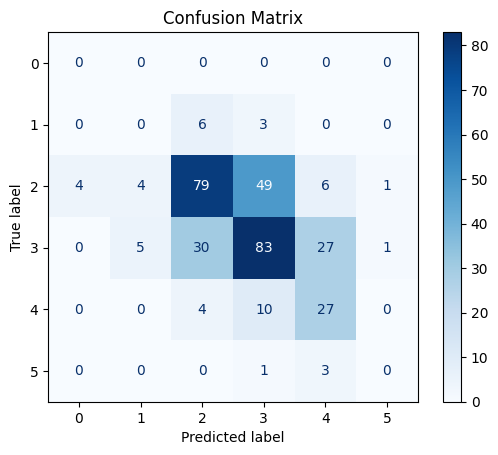

[[ 0  0  0  0  0  0]
 [ 0  0  6  3  0  0]
 [ 4  4 79 49  6  1]
 [ 0  5 30 83 27  1]
 [ 0  0  4 10 27  0]
 [ 0  0  0  1  3  0]]


In [7]:
wine_model, wine_preds, wine_actual = run_naive_bayes(
    file_path='WineQT.csv', 
    target_col='quality'
)

Loading and processing: Titanic-Dataset.csv...
--- Results for Titanic-Dataset.csv ---
Accuracy: 0.7910

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.82       157
           1       0.74      0.77      0.75       111

    accuracy                           0.79       268
   macro avg       0.78      0.79      0.79       268
weighted avg       0.79      0.79      0.79       268



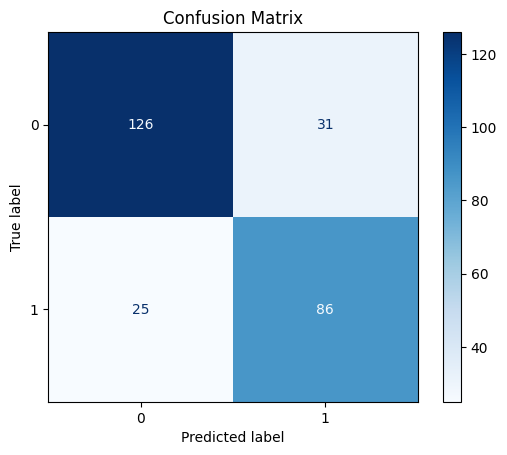

[[126  31]
 [ 25  86]]


In [8]:
titanic_model, titanic_preds, titanic_actual = run_naive_bayes(
    file_path='Titanic-Dataset.csv', 
    target_col='Survived',
    cols_to_drop=['PassengerId', 'Name', 'Ticket', 'Cabin'] 
)

Loading and processing: BreastCancer.csv...
--- Results for BreastCancer.csv ---
Accuracy: 0.9357

Classification Report:
              precision    recall  f1-score   support

           B       0.94      0.95      0.95       108
           M       0.92      0.90      0.91        63

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



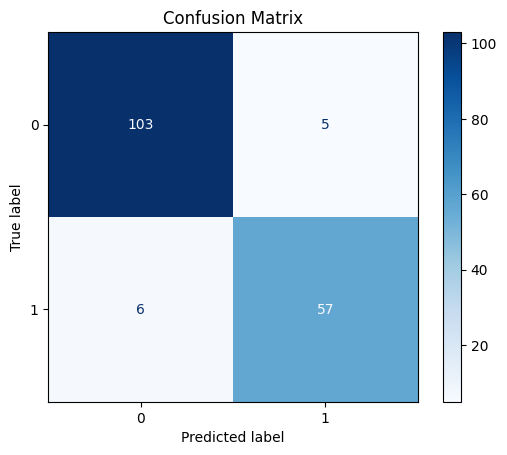

[[103   5]
 [  6  57]]


In [9]:
cancer_model, cancer_preds, cancer_actual = run_naive_bayes(
    file_path='BreastCancer.csv', 
    target_col='diagnosis', 
    cols_to_drop=['id', 'Unnamed: 32'] 
)